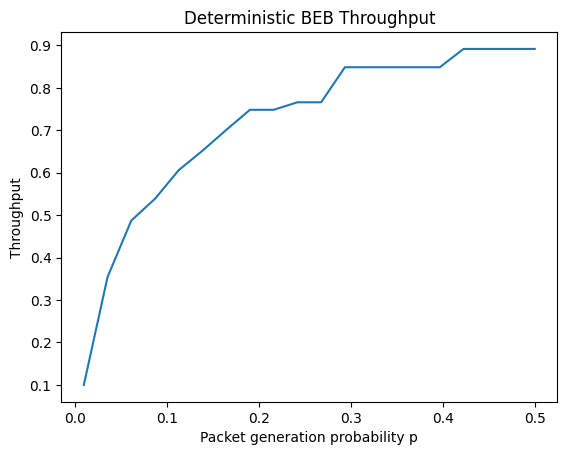

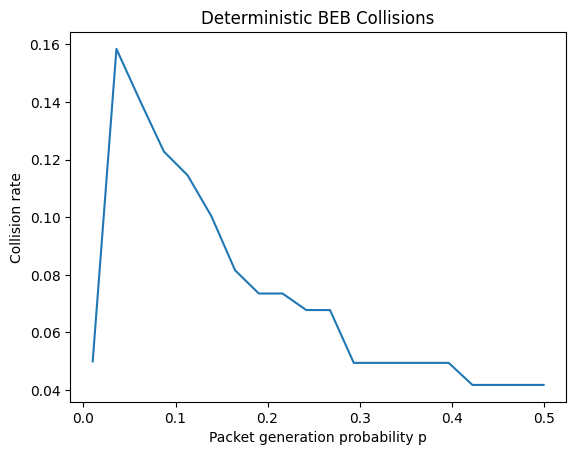

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10
T = 50000
CW_MIN = 4
CW_MAX = 1024

p_values = np.linspace(0.01,0.5,20)


class Node:

    def __init__(self,p,node_id):

        self.p = p
        self.node_id = node_id

        self.arrival_interval = max(1,int(round(1/p)))

        self.queue = 0
        self.cw = CW_MIN
        self.backoff = (CW_MIN//2 + node_id) % CW_MIN

    def arrival(self,slot):

        if (slot + self.node_id) % self.arrival_interval == 0:
            self.queue += 1

    def decrement_backoff(self):

        if self.queue > 0 and self.backoff > 0:
            self.backoff -= 1

    def ready(self):

        return self.queue > 0 and self.backoff == 0

    def success(self):

        self.queue -= 1
        self.cw = CW_MIN
        self.backoff = (self.cw//2 + self.node_id) % self.cw

    def collision(self):

        self.cw = min(self.cw*2,CW_MAX)
        self.backoff = (self.cw//2 + self.node_id) % self.cw


def run_simulation(p):

    nodes = [Node(p,i) for i in range(N)]

    successes = 0
    collisions = 0

    for slot in range(T):

        for node in nodes:
            node.arrival(slot)

        for node in nodes:
            node.decrement_backoff()

        transmitters = [node for node in nodes if node.ready()]

        if len(transmitters) == 1:

            successes += 1
            transmitters[0].success()

        elif len(transmitters) > 1:

            collisions += 1

            for node in transmitters:
                node.collision()

    throughput = successes/T
    collision_rate = collisions/T

    return throughput,collision_rate


throughputs = []
collisions = []

for p in p_values:

    thr,col = run_simulation(p)

    throughputs.append(thr)
    collisions.append(col)


plt.figure()
plt.plot(p_values,throughputs)
plt.xlabel("Packet generation probability p")
plt.ylabel("Throughput")
plt.title("Deterministic BEB Throughput")
plt.show()


plt.figure()
plt.plot(p_values,collisions)
plt.xlabel("Packet generation probability p")
plt.ylabel("Collision rate")
plt.title("Deterministic BEB Collisions")
plt.show()